# Peramalan Kadar NO₂ di Wilayah Kota Sumenep

## Latar Belakang

Penelitian ini difokuskan pada wilayah Kota Sumenep sebagai pusat aktivitas transportasi, permukiman, dan perdagangan di Kabupaten Sumenep. Seiring meningkatnya aktivitas tersebut, potensi pencemaran udara akibat emisi kendaraan bermotor, pembakaran bahan bakar fosil, dan aktivitas lainnya juga semakin meningkat.

Salah satu polutan udara yang menjadi perhatian adalah Nitrogen Dioksida (NO₂). NO₂ merupakan gas pencemar yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit energi, dan aktivitas industri. Konsentrasi NO₂ yang tinggi dapat menyebabkan gangguan sistem pernapasan, iritasi saluran pernapasan, memperburuk penyakit asma dan bronkitis, serta berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan.

Pemantauan konsentrasi NO₂ menjadi penting untuk mengetahui kondisi kualitas udara suatu wilayah dan mengidentifikasi perubahan konsentrasinya dari waktu ke waktu. Dengan memanfaatkan data penginderaan jauh dari satelit Sentinel-5P, konsentrasi NO₂ dapat diamati secara berkala dan mencakup wilayah yang luas. Data tersebut selanjutnya digunakan untuk melakukan analisis dan peramalan kadar NO₂ di wilayah Kota Sumenep sebagai dasar pengambilan keputusan dalam pengelolaan lingkungan di masa mendatang.

## 1. Pengumpulan Data

Tahap pertama adalah mengumpulkan data time series harian kadar NO₂ di wilayah Kota Sumenep menggunakan platform Copernicus Data Space Ecosystem yang menyediakan data satelit Sentinel-5P. Data diambil menggunakan Python melalui JupyterLab dengan menentukan batas wilayah penelitian (Area of Interest/AOI) serta rentang waktu pengamatan yang dibutuhkan.

### Library yang Digunakan

In [6]:
import openeo
import netCDF4
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### 1.1 Instalasi dan Koneksi OpenEO

```bash
pip install openeo

```

In [7]:
connection = openeo.connect(
    "openeo.dataspace.copernicus.eu"
).authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=JHTK-SLNK 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Saat kode dijalankan, pengguna akan diminta melakukan autentikasi melalui akun Copernicus.

### 1.2 Menentukan Area of Interest (AOI)

In [8]:
aoi_sumenep = {
    "type": "Polygon",
    "coordinates": [[
        [113.8116313, -7.0348873],
        [113.8116313, -6.9847008],
        [113.9047341, -6.9847008],
        [113.9047341, -7.0348873],
        [113.8116313, -7.0348873]
    ]]
}

Koordinat AOI dapat diperoleh melalui website GeoJSON.io dengan membuat polygon pada wilayah penelitian.

AOI digunakan untuk membatasi wilayah pengamatan pada Kota Sumenep.

### 1.3 Pengambilan Data Sentinel-5P

In [9]:
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=[
        "2023-10-01",
        "2025-10-01"
    ],
    spatial_extent={
        "west":113.8116313,
        "south":-7.0348873,
        "east":113.9047341,
        "north":-6.9847008
    },
    bands=["NO2"]
)
# rata-rata harian
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# rata-rata seluruh AOI
# agregasi spasial dibuat untuk analisis AOI
# namun output NetCDF diambil dari agregasi temporal
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi_sumenep
)

### 1.4 Menjalankan Batch Job

Batch job digunakan untuk menjalankan proses pengambilan data Sentinel-5P secara asinkron pada server Copernicus. Hasil crawling kemudian disimpan dalam format NetCDF (.nc) sehingga memudahkan proses ekstraksi, pembersihan, dan pembentukan data time series.

In [10]:
job = s5p_no2_daily.execute_batch(
    title="NO2 Sumenep Daily Mean", 
    outputfile="NO2Sumenep.nc"
)

0:00:00 Job 'j-2606110112504df68b19a8a82068722e': send 'start'
0:00:02 Job 'j-2606110112504df68b19a8a82068722e': queued (progress 0%)
0:00:08 Job 'j-2606110112504df68b19a8a82068722e': queued (progress 0%)
0:00:15 Job 'j-2606110112504df68b19a8a82068722e': queued (progress 0%)
0:00:23 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:00:33 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:00:46 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:01:02 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:01:26 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:01:50 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:02:20 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:02:58 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:03:45 Job 'j-2606110112504df68b19a8a82068722e': running (progress N/A)
0:04:44 Job 'j-2606110112504df68b19a8a82068722e': running (progress

In [11]:
ds = netCDF4.Dataset("NO2Sumenep.nc")

print("Variabel dalam file NetCDF:")
print(ds.variables.keys())

no2 = ds.variables["NO2"][:]

time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units

    dates = netCDF4.num2date(
        time,
        units=time_units
    )

except Exception:

    dates = time

Variabel dalam file NetCDF:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


## 2. Preprocessing Data

Data hasil crawling disimpan dalam format NetCDF (.nc). Pada tahap preprocessing, data dibaca dan dibersihkan sebelum digunakan untuk proses analisis dan peramalan. Pastikan library netCDF4 sudah ter-install.

```bash
pip install netCDF4
```

### 2.1 Membaca File NetCDF

In [12]:
print("Berhasil konversi waktu")
print(dates[:5])

Berhasil konversi waktu
[cftime.DatetimeGregorian(2023, 10, 1, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2023, 10, 2, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2023, 10, 3, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2023, 10, 4, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2023, 10, 5, 0, 0, 0, 0, has_year_zero=False)]


### 2.2 Mengatasi Missing Value dengan Interpolasi Linear

Grafik berikut menunjukkan data NO₂ sebelum proses interpolasi. Terlihat terdapat beberapa nilai yang hilang (missing value) sehingga perlu dilakukan proses interpolasi linear agar data menjadi lebih lengkap.

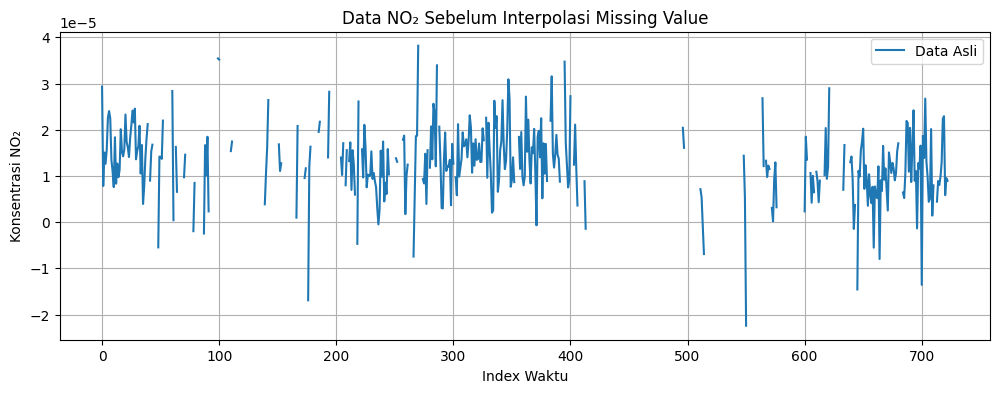

In [13]:
plt.figure(figsize=(12,4))

plt.plot(
    np.mean(no2, axis=(1,2)),
    label="Data Asli"
)

plt.title("Data NO₂ Sebelum Interpolasi Missing Value")
plt.xlabel("Index Waktu")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.legend()

plt.show()

In [14]:
no2_filled = no2.copy()

if hasattr(no2_filled, "filled"):
    no2_filled = no2_filled.filled(np.nan)

for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2_filled[:, i, j])
        no2_filled[:, i, j] = (
            series.interpolate(
                method='linear',
                limit_direction='both'
            ).to_numpy()
        )

Setelah dilakukan interpolasi linear, nilai yang hilang berhasil diisi sehingga data menjadi lebih kontinu dan dapat digunakan pada tahap berikutnya.

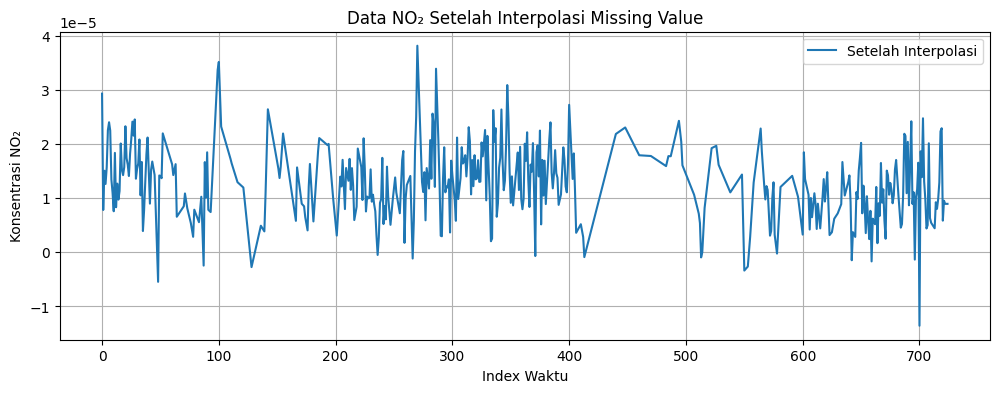

In [15]:
plt.figure(figsize=(12,4))

plt.plot(
    np.mean(no2_filled, axis=(1,2)),
    label="Setelah Interpolasi"
)

plt.title("Data NO₂ Setelah Interpolasi Missing Value")
plt.xlabel("Index Waktu")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.legend()

plt.show()

### 2.3 Membentuk Data Harian

In [16]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_dates.append(
        dates[i].strftime('%Y-%m-%d')
    )
    new_no2.append(
        np.mean(no2_filled[i])
    )

### 2.4 Menyimpan ke CSV

In [17]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv(
    "NO2_Sumenep_timeseries.csv",
    index=False
)
print(df.head())

         date       NO2
0  2023-10-01  0.000029
1  2023-10-02  0.000008
2  2023-10-03  0.000015
3  2023-10-04  0.000013
4  2023-10-05  0.000016


## 3. Pengecekan Missing Date pada Data Harian

In [18]:
full_range = pd.date_range(
    start="2023-10-01",
    end="2025-10-01",
    freq='D'
)

missing_dates = full_range.difference(
    df['date']
)
print("Jumlah Missing Date:", len(missing_dates))
df["date"] = pd.to_datetime(df["date"])

df = (
    df.set_index("date")
      .reindex(full_range)
)

df.index.name = "date"

df["NO2"] = (
    df["NO2"]
    .interpolate(method="time")
    .bfill()
    .ffill()
)

Jumlah Missing Date: 732


Tanggal yang hilang pada rentang pengamatan diisi menggunakan interpolasi berbasis waktu (time interpolation) sehingga diperoleh deret waktu harian yang lengkap dan kontinu.

Histogram digunakan untuk melihat distribusi data NO₂ sebelum proses deteksi outlier. Visualisasi ini membantu memahami pola sebaran data dan mengidentifikasi kemungkinan nilai ekstrem.

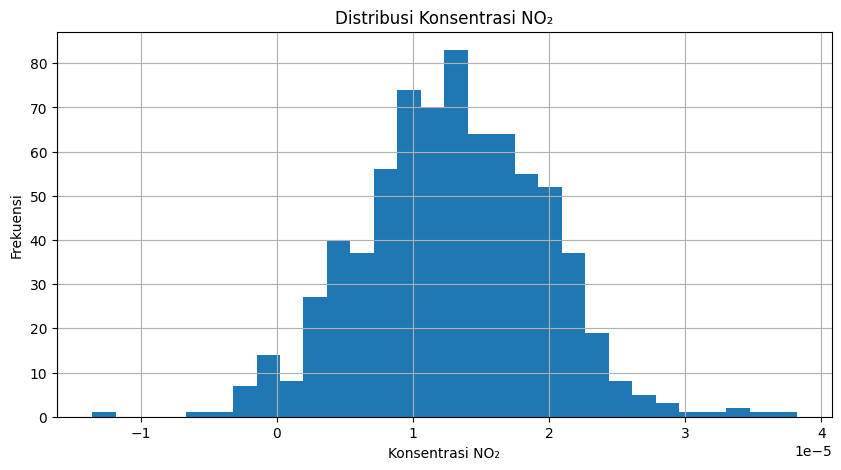

In [19]:
plt.figure(figsize=(10,5))

plt.hist(
    df["NO2"],
    bins=30
)

plt.title("Distribusi Konsentrasi NO₂")
plt.xlabel("Konsentrasi NO₂")
plt.ylabel("Frekuensi")

plt.grid(True)

plt.show()

## 4. Deteksi dan Penanganan Outlier

Metode yang digunakan adalah Interquartile Range (IQR).

In [20]:
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
]

print("Jumlah Outlier:", len(outliers))

Jumlah Outlier: 7


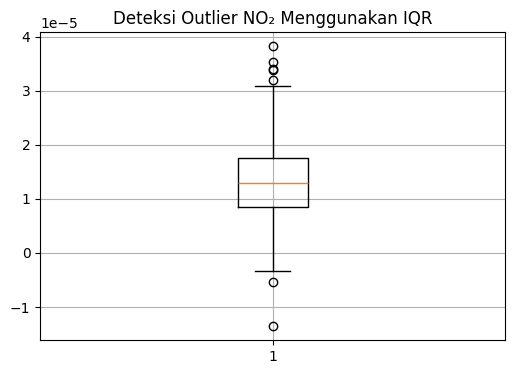

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(df["NO2"])
plt.title("Deteksi Outlier NO₂ Menggunakan IQR")
plt.grid(True)
plt.show()

Data yang terdeteksi sebagai outlier diubah menjadi NaN kemudian diisi kembali menggunakan interpolasi linear.

In [22]:
df['NO2_cleaned'] = df['NO2'].mask(
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
)

df['NO2_filled'] = (
    df['NO2_cleaned']
    .interpolate(method='linear')
    .bfill()
    .ffill()
)


Grafik berikut memperlihatkan perbandingan data sebelum dan sesudah penanganan outlier. Nilai yang terdeteksi sebagai outlier diubah menjadi NaN dan kemudian diisi kembali menggunakan interpolasi linear sehingga diperoleh deret waktu yang lebih stabil dan siap digunakan untuk proses pemodelan.

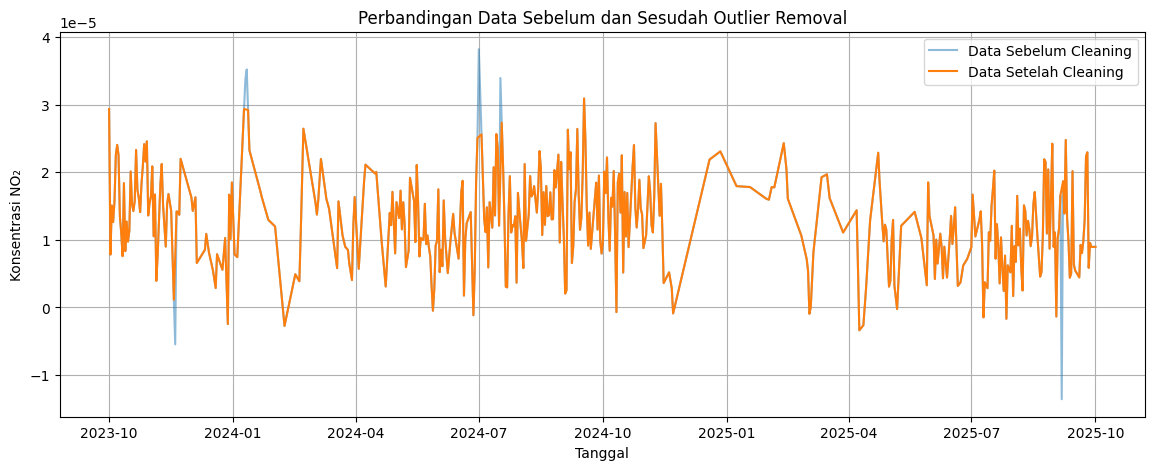

In [23]:
plt.figure(figsize=(14,5))

plt.plot(
    df.index,
    df['NO2'],
    label='Data Sebelum Cleaning',
    alpha=0.5
)

plt.plot(
    df.index,
    df['NO2_filled'],
    label='Data Setelah Cleaning'
)

plt.title("Perbandingan Data Sebelum dan Sesudah Outlier Removal")

plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")

plt.grid(True)

plt.legend()

plt.show()

In [24]:
final_df = pd.DataFrame({
    "date": df.index,
    "NO2": df["NO2_filled"]
})

final_df.to_csv(
    "NO2_Sumenep_Final.csv",
    index=False
)

print("Dataset final berhasil disimpan")
print(final_df.head())

Dataset final berhasil disimpan
                 date       NO2
date                           
2023-10-01 2023-10-01  0.000029
2023-10-02 2023-10-02  0.000008
2023-10-03 2023-10-03  0.000015
2023-10-04 2023-10-04  0.000013
2023-10-05 2023-10-05  0.000016


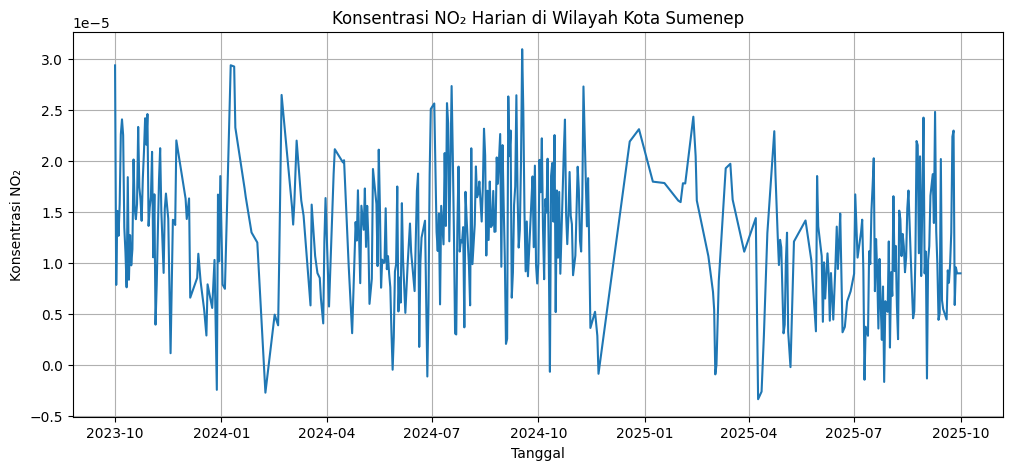

In [25]:
plt.figure(figsize=(12,5))

plt.plot(
    final_df["date"],
    final_df["NO2"]
)

plt.title("Konsentrasi NO₂ Harian di Wilayah Kota Sumenep")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True)
plt.show()

## 5. Persiapan Data untuk Pemodelan
### 5.1 Transformasi Time Series ke Supervised Learning

In [26]:
def create_supervised(
    data,
    n_lag=4
):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[
            f'NO2(t-{i})'
        ] = data.shift(i)

    df_supervised['NO2(t)'] = data

    df_supervised.dropna(
        inplace=True
    )

    return df_supervised

### 5.2 Standardisasi Data

In [27]:
scaler = StandardScaler()

df['NO2_scaled'] = (
    scaler.fit_transform(
        df['NO2_filled']
        .values.reshape(-1,1)
    ).flatten()
)

### 5.3 Uji Korelasi Lag

In [28]:
supervised_df30 = create_supervised(
    df['NO2_scaled'],
    n_lag=30
)

correlations = (
    supervised_df30
    .drop(columns='NO2(t)')
    .corrwith(
        supervised_df30['NO2(t)']
    )
)
print(correlations.sort_values(
    ascending=False
).head(10))

NO2(t-1)     0.716038
NO2(t-2)     0.560834
NO2(t-3)     0.428481
NO2(t-5)     0.382781
NO2(t-4)     0.371858
NO2(t-6)     0.305300
NO2(t-7)     0.235695
NO2(t-8)     0.163774
NO2(t-11)    0.145435
NO2(t-10)    0.138885
dtype: float64


Hasil korelasi digunakan untuk menentukan jumlah lag terbaik yang akan digunakan dalam proses prediksi kadar NO₂ harian.

## 6. Kesimpulan

Data NO₂ wilayah Kota Sumenep diperoleh dari satelit Sentinel-5P melalui Copernicus Data Space Ecosystem. Setelah dilakukan preprocessing berupa penanganan missing value, pembentukan data harian, penanganan missing date menggunakan interpolasi berbasis waktu, serta penghapusan outlier menggunakan metode IQR, data siap digunakan untuk proses peramalan.

Visualisasi data menunjukkan bahwa proses preprocessing berhasil menghasilkan deret waktu NO₂ yang lebih lengkap dan stabil sehingga siap digunakan pada tahap pemodelan dan peramalan.